In [13]:
import pandas as pd
import os

# Define the file path using a raw string to handle Windows backslashes safely
file_path = r"C:\Users\matias\Documents\Vision-Aided-Beamformer\tests\dataset_out\Avance_1\benchmark_A.parquet"

# Verify if the file exists before attempting to load it
if os.path.exists(file_path):
    # Load the Parquet file into a Pandas DataFrame
    df_metrics = pd.read_parquet(file_path)
    
    # Filter out all rows where rt60 is 0.0 (anechoic conditions) and reset the index
    df_metrics = df_metrics[df_metrics['rt60'] > 0.0].reset_index(drop=True)
    
    print(f"Dataset successfully loaded and filtered (RT60 > 0.0)! Shape: {df_metrics.shape}\n")
    
    # Display the first few rows to confirm data integrity
    display(df_metrics.head())
    
    # Optional: Print all column names to quickly review the available metrics
    # print("Available columns:", df_metrics.columns.tolist())
else:
    print(f"Error: File not found at the specified path:\n{file_path}")
    print("Please check your current working directory using 'import os; print(os.getcwd())'.")

Dataset successfully loaded and filtered (RT60 > 0.0)! Shape: (480, 53)



,processor,rt60,M,N_interferences,mismatch_pos,isir_db,mismatch_gain,mismatch_phase,use_wpe,t_early_s,...,Delta_bf_SIR,Delta_bf_SAR,Delta_bf_SINR,Delta_tot_PESQ,Delta_tot_STOI,Delta_tot_CD,Delta_tot_SDR,Delta_tot_SIR,Delta_tot_SAR,Delta_tot_SINR
0,DS,0.3,4,1,0.0,0,0,0,False,0.024,...,1.001037,0.698812,1.352581,0.063068,0.052456,-1.059660,1.030900,1.001037,0.698812,1.352581
1,MVDR_(VAD)),0.3,4,1,0.0,0,0,0,False,0.024,...,1.922964,-0.544392,2.037188,0.120515,0.083597,-1.547192,1.444275,1.922964,-0.544392,2.037188
2,RTF-MVDR (VAD),0.3,4,1,0.0,0,0,0,False,0.024,...,11.046063,0.609317,11.313811,0.103855,0.080571,-0.147712,7.384764,11.046063,0.609317,11.313811
3,MVDR_SPP,0.3,4,1,0.0,0,0,0,False,0.024,...,0.855107,-1.552865,1.001850,0.070976,0.061523,-1.489623,0.262848,0.855107,-1.552865,1.001850
4,MPDR,0.3,4,1,0.0,0,0,0,False,0.024,...,2.062744,-1.301733,2.199565,0.077645,0.065626,-1.273243,1.291675,2.062744,-1.301733,2.199565


In [47]:
# ==============================================================================
# BLOCK 1: GLOBAL STYLING MACROS AND EXPORT PATHS
# ==============================================================================
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define the root directory to save all generated figures for the thesis
FIGURES_DIR = r"C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Configure the global plotting style to match academic LaTeX standards
def set_thesis_plot_style():
    """
    Applies global formatting rules for Matplotlib and Seaborn.
    Uses a serif font and sizes appropriate for an A4 LaTeX document.
    """
    sns.set_theme(style="whitegrid", context="paper")
    
    plt.rcParams.update({
        "font.family": "serif",          # Matches standard LaTeX font
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 11,                 # Base font size
        "axes.titlesize": 16,            # Subplot title size
        "axes.labelsize": 16,            # X and Y label size
        "xtick.labelsize": 13,            # Tick labels
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "legend.title_fontsi3e": 13,
        "figure.titlesize": 22,
        "figure.dpi": 500,               # High resolution for print
        "savefig.dpi": 500,
        "savefig.bbox": "tight",         # Removes unnecessary white space
        "lines.linewidth": 1,
        "lines.markersize": 5
    })

# Apply the style settings
set_thesis_plot_style()

KeyError: 'legend.title_fontsi3e is not a valid rc parameter (see rcParams.keys() for a list of valid parameters)'

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\mics_no_wpe.pdf


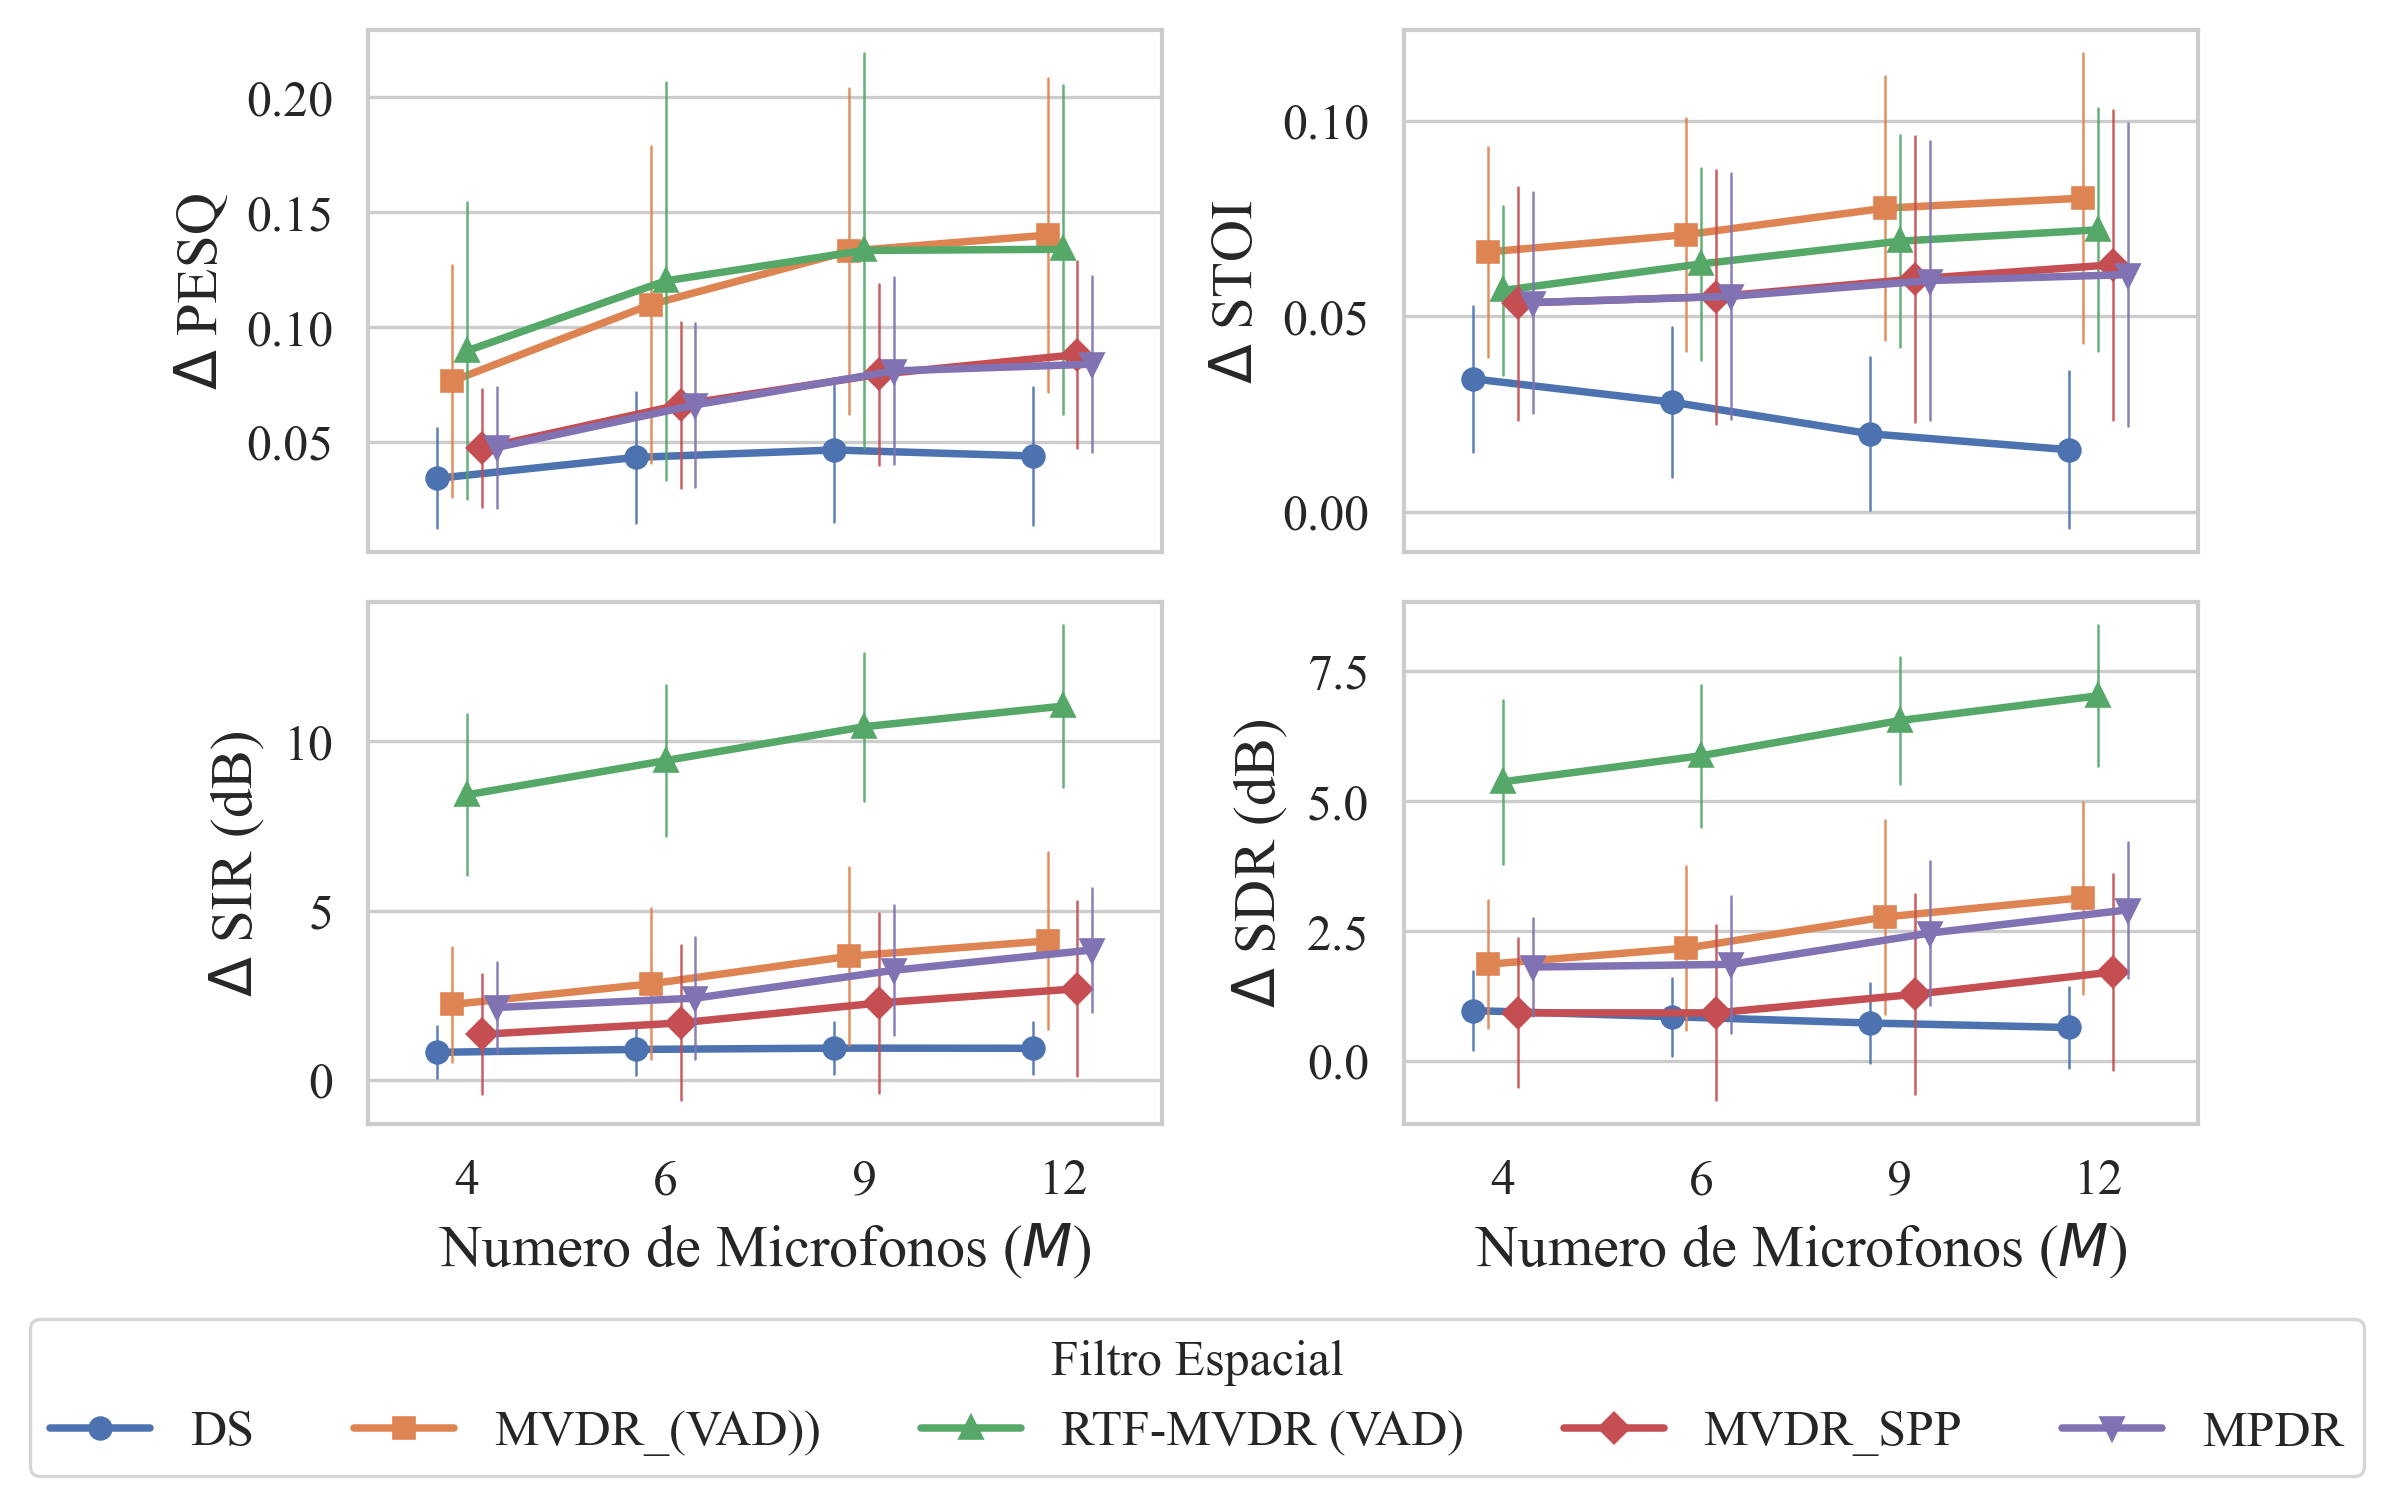

In [32]:

def plot_beamformer_deltas_vs_m_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis 
    to maximize plotting area.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == True].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SDR': r'$\Delta$ SDR (dB)'
    }
    
    # Create a 2x2 subplot grid
    # Height adjusted back to 5.0 since we removed the titles
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='M', 
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Numero de Microfonos ($M$)')
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Filtro Espacial',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "mics_no_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_m_compact(df_metrics)



Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\deltas_vs_interferences.pdf


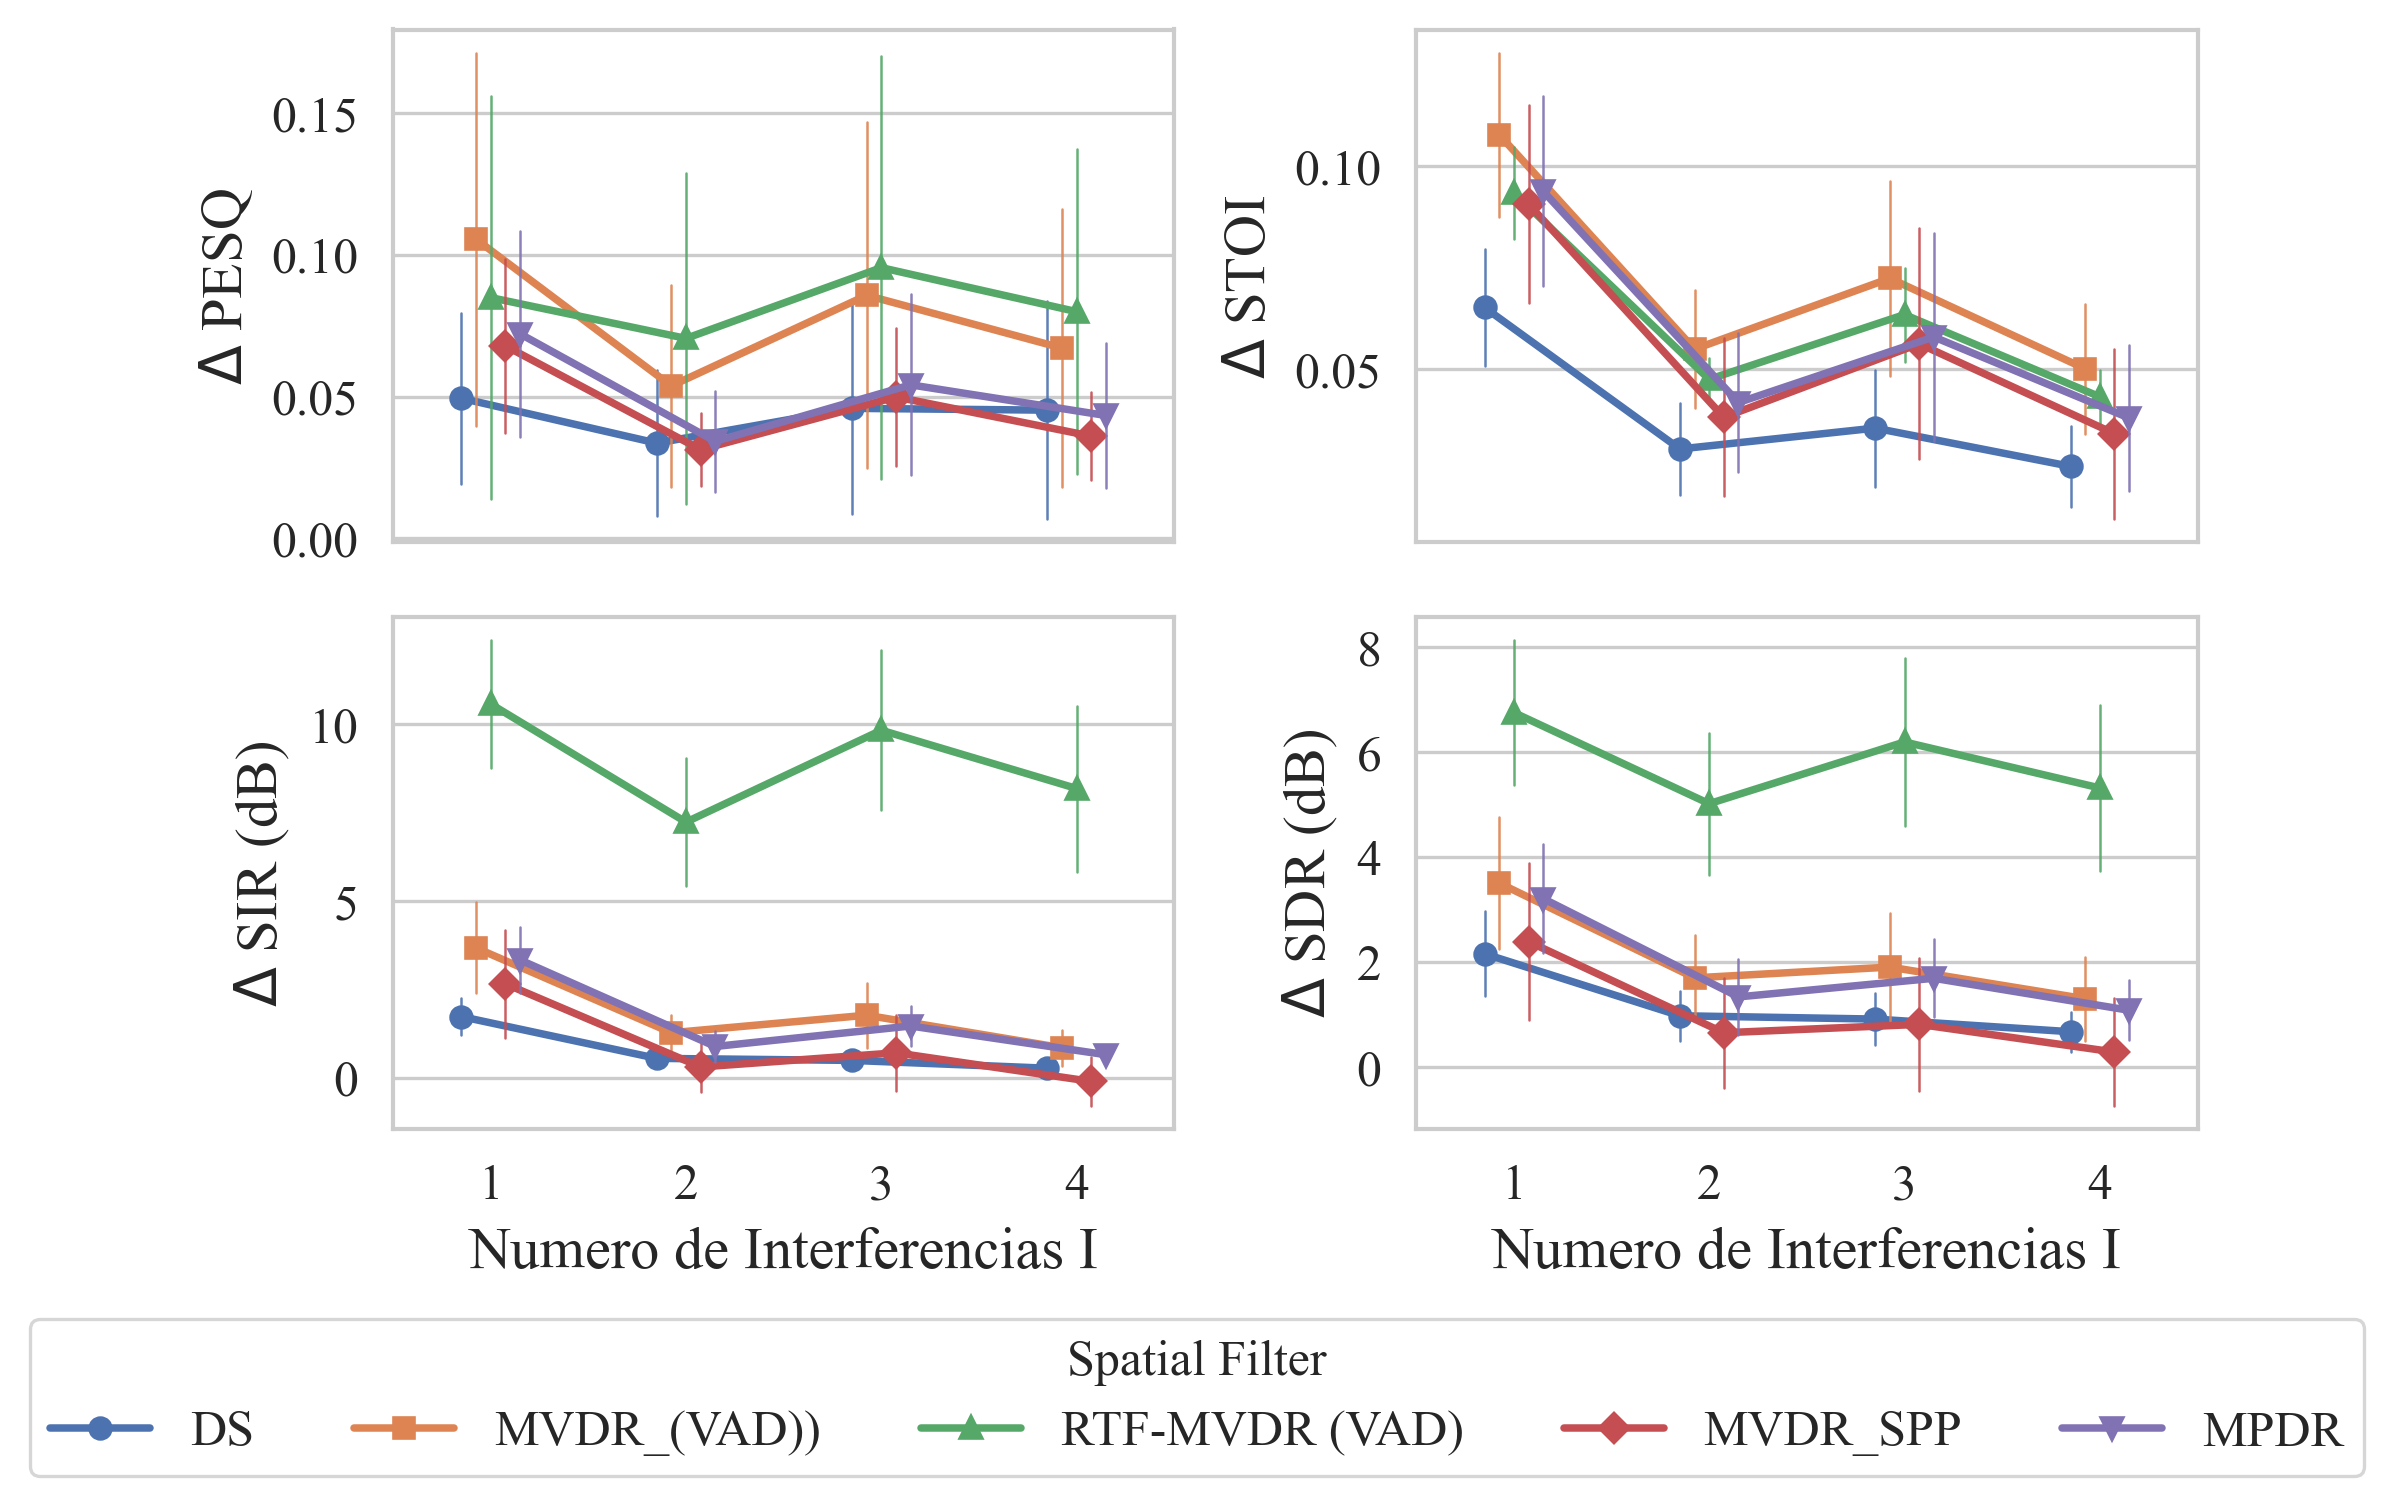

In [29]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == False].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SDR': r'$\Delta$ SDR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='N_interferences',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        # -------------------------------------------------------------
        # INVERT Y-AXIS SPECIFICALLY FOR SAR
        # -------------------------------------------------------------

        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Numero de Interferencias I') # Updated label
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        if 'SAR' in metric_col:
            ax.invert_yaxis()     
        

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Spatial Filter',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "deltas_vs_interferences.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\t60_sin_wpe.pdf


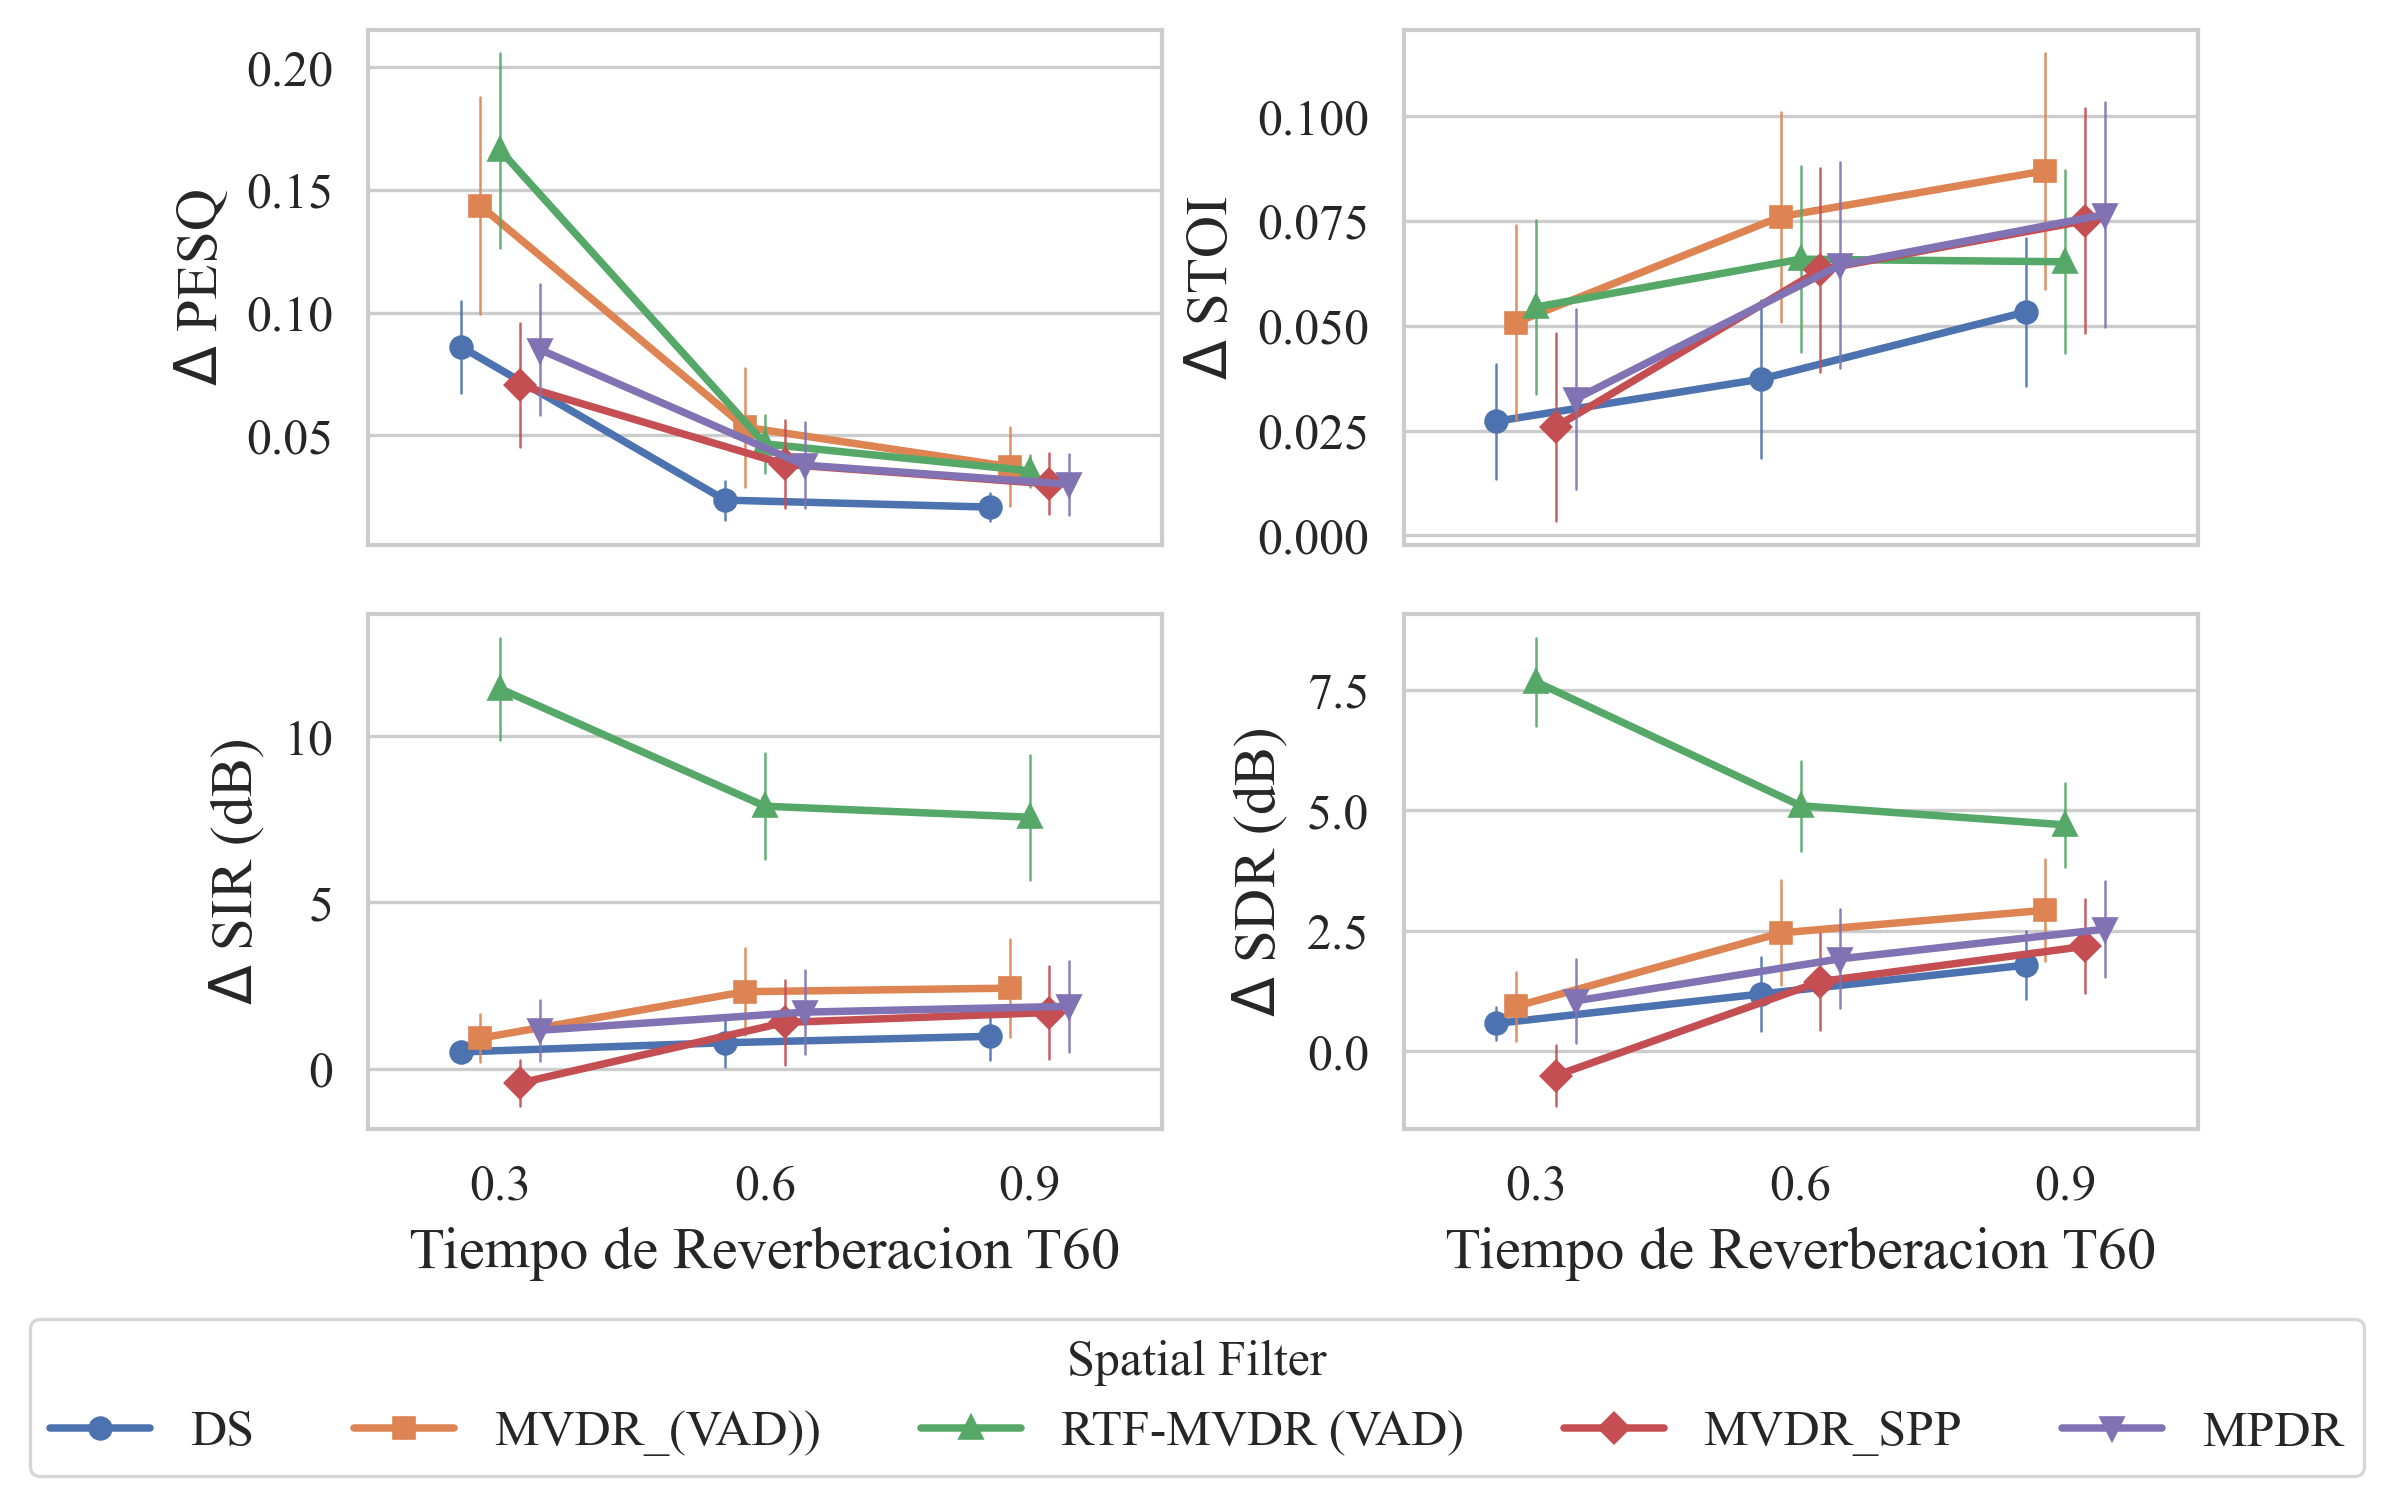

In [33]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == False].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SDR': r'$\Delta$ SDR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2,figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='rt60',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberacion T60') # Updated label
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Spatial Filter',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "t60_sin_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\t60_con_wpe.pdf


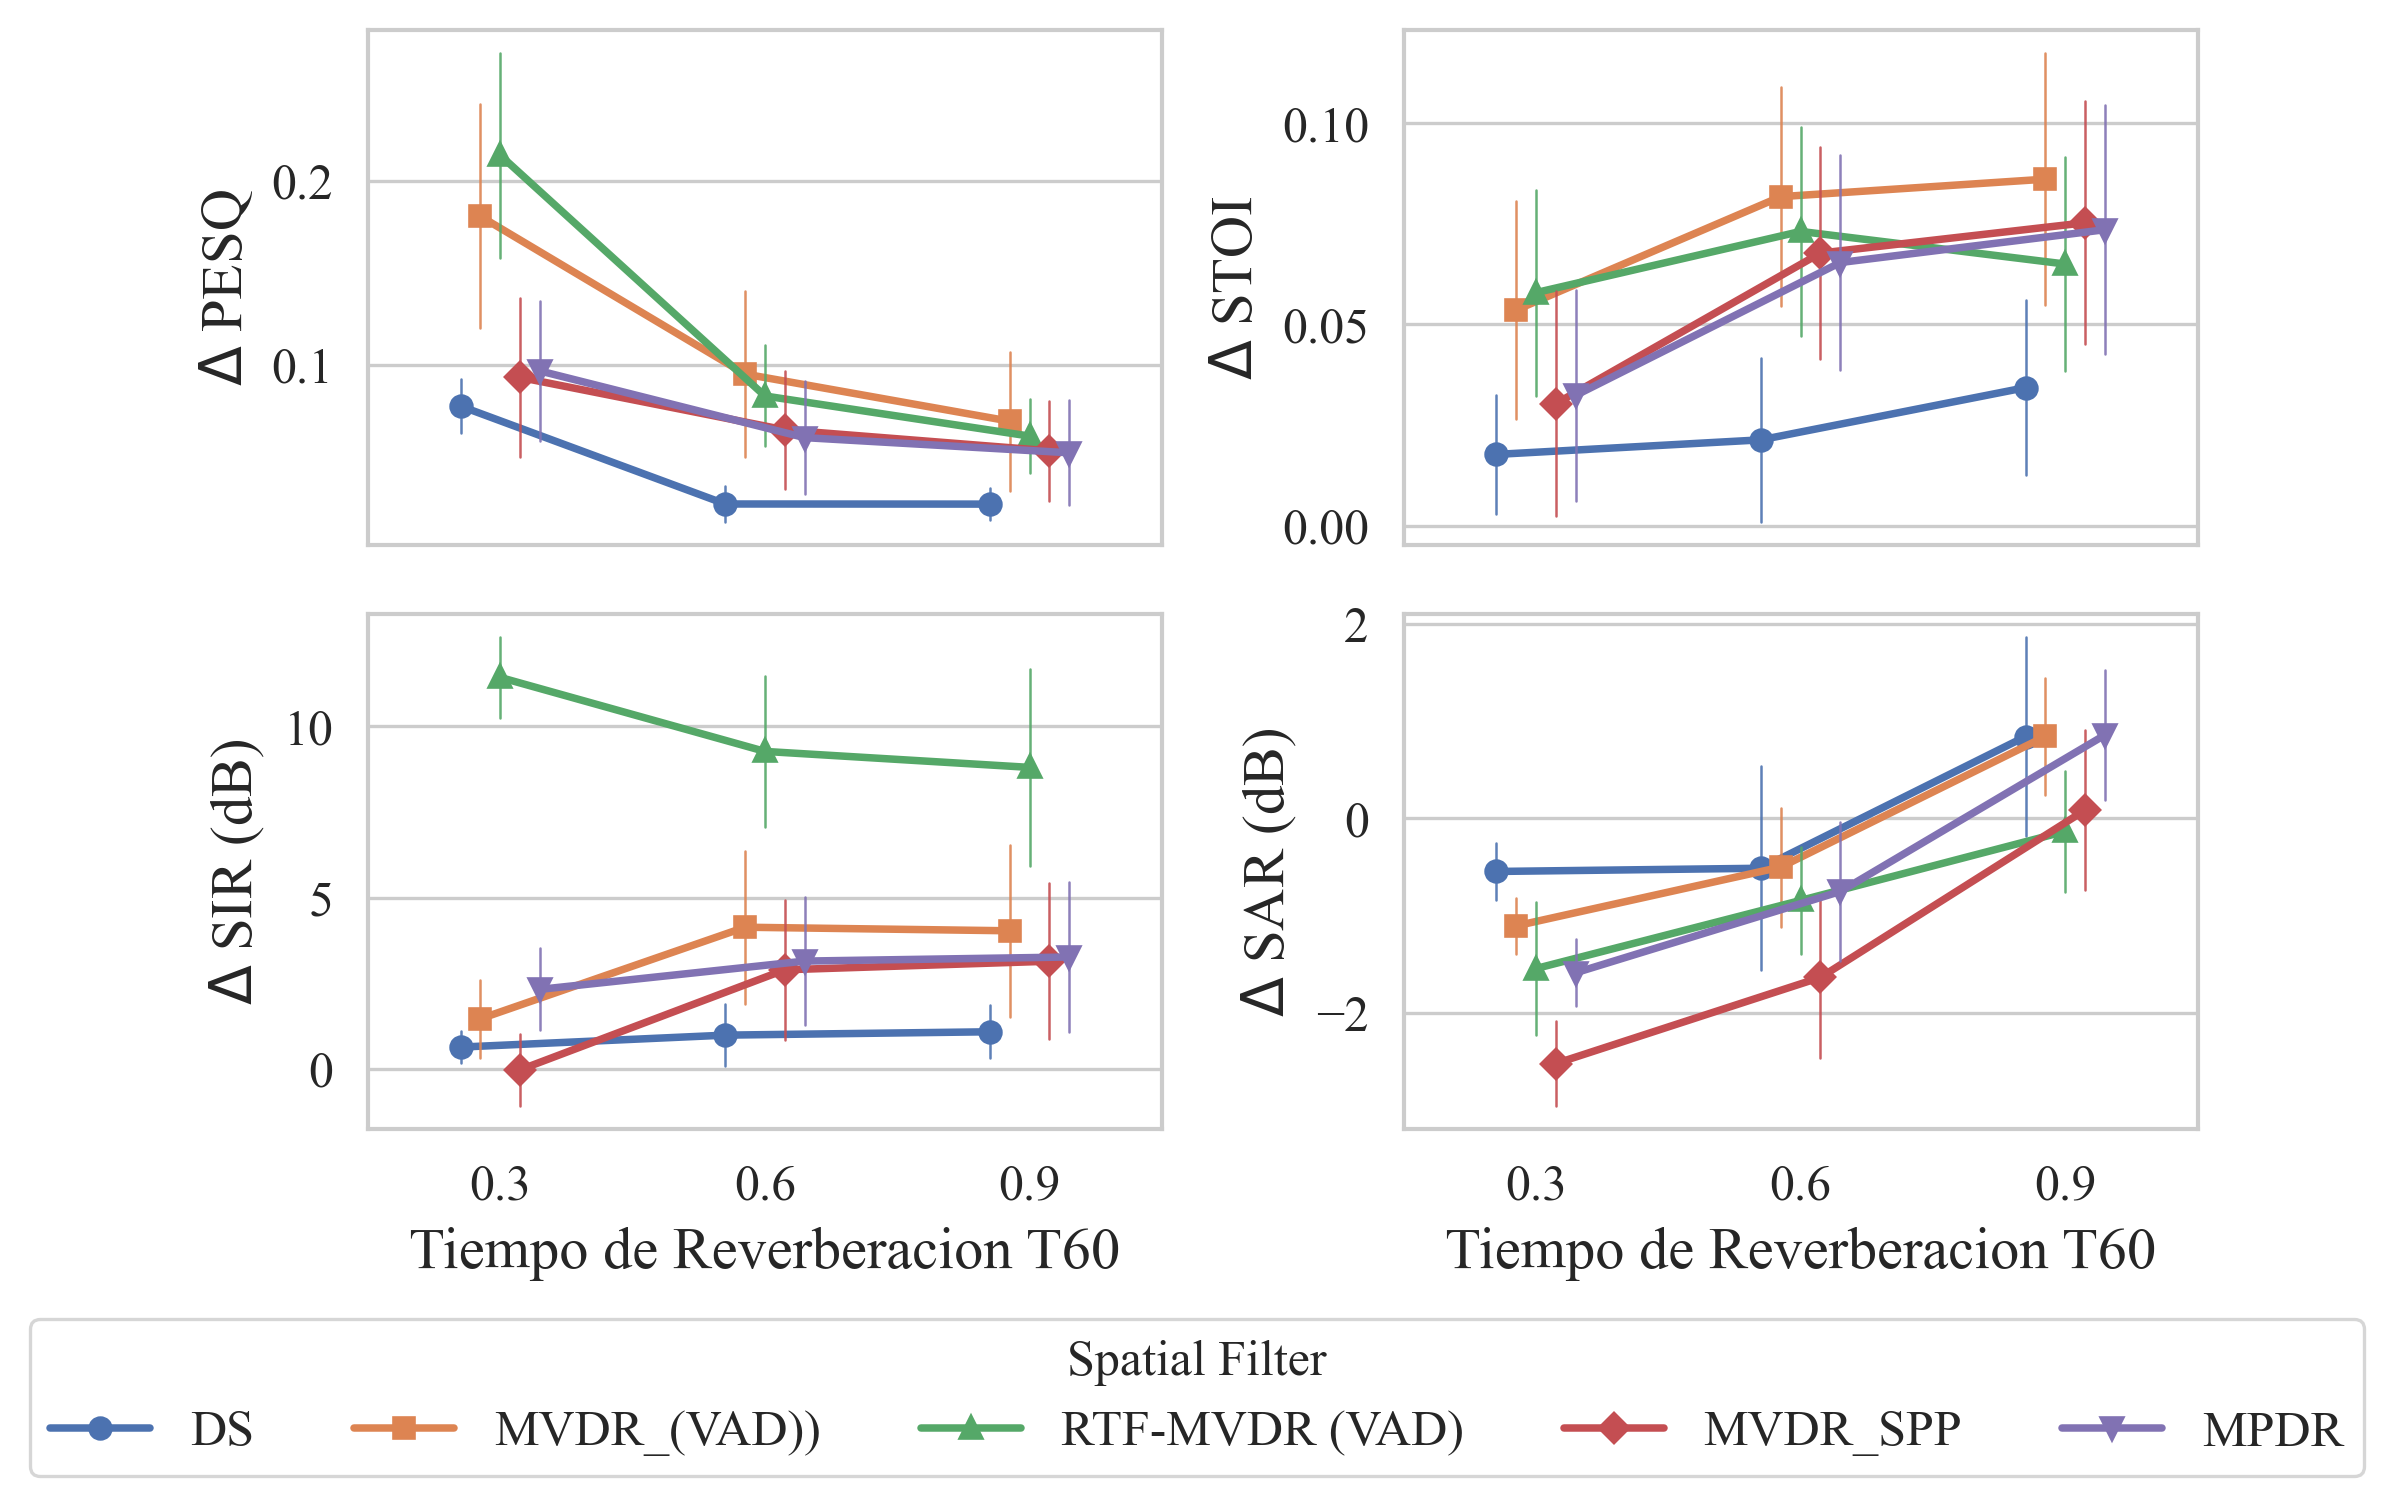

In [25]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == True].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='rt60',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberacion T60') # Updated label
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Spatial Filter',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "t60_con_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\deltas_vs_rt_wpe_sin_con.pdf


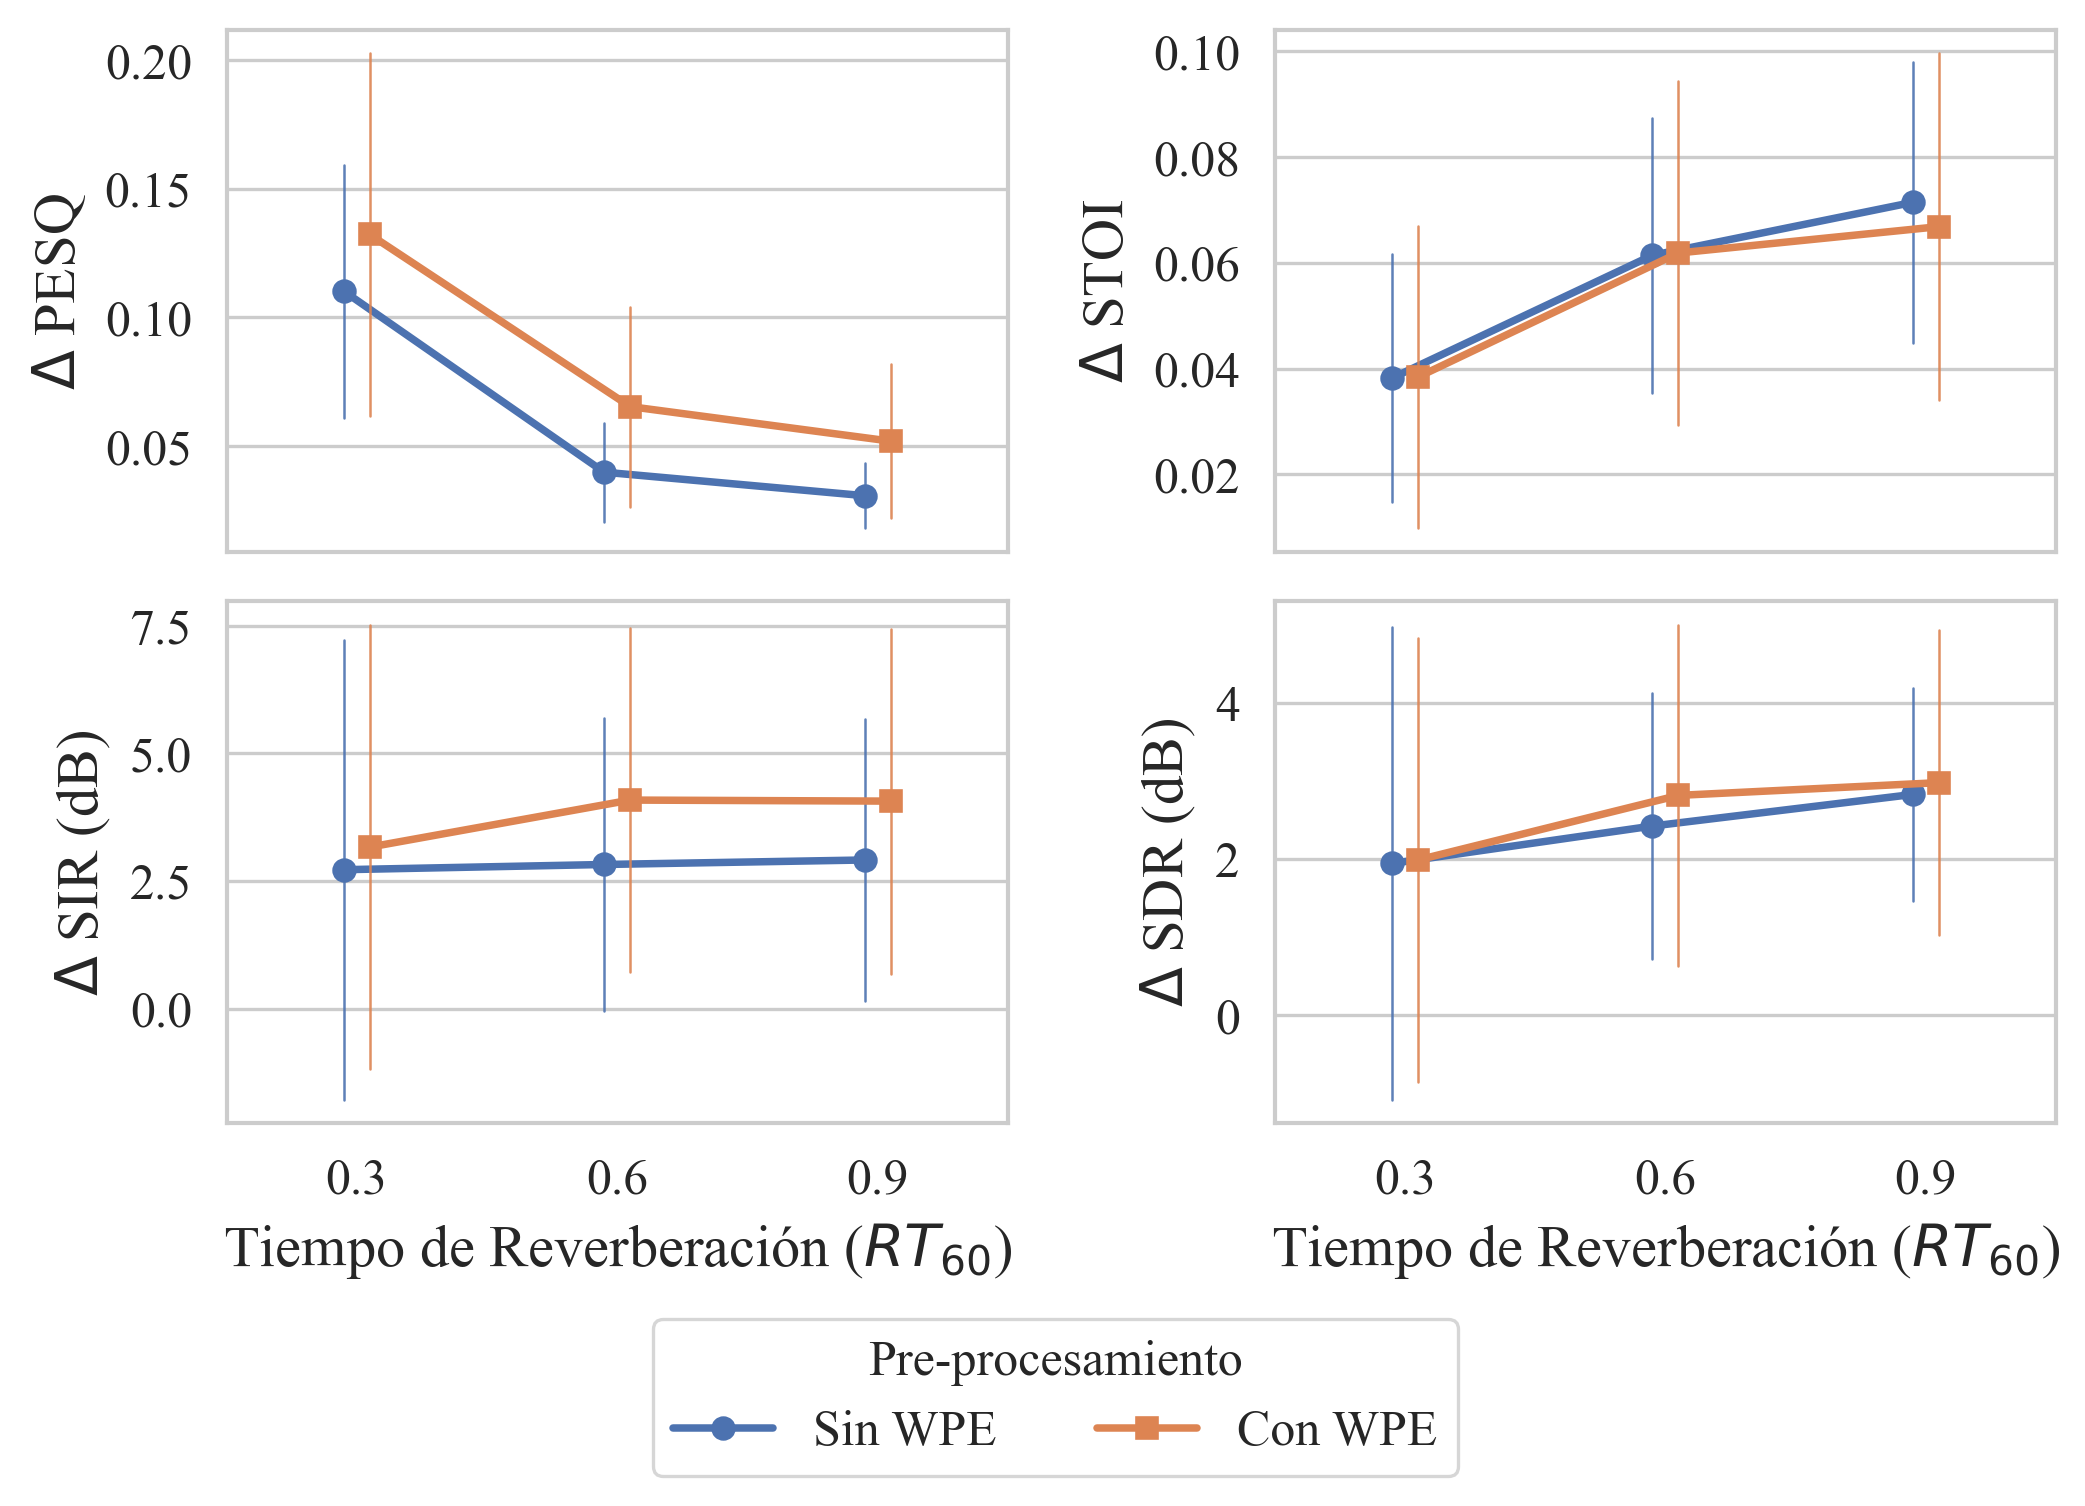

In [30]:
# ==============================================================================
# BLOCK 4: GENERATE WPE COMPARISON PLOT (AVERAGED ACROSS ALL PROCESSORS)
# ==============================================================================

def plot_wpe_comparison_vs_rt60(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR).
    Averages the performance of all spatial filters and compares the results 
    with and without WPE pre-processing over different reverberation times.
    """
    # We need the full dataset (no WPE filter applied here)
    df_plot = df.copy()
    
    # Create a new column with readable labels for the legend
    df_plot['Condición WPE'] = df_plot['use_wpe'].map({True: 'Con WPE', False: 'Sin WPE'})
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SDR': r'$\Delta$ SDR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2,figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Only two markers needed now
    markers = ['o', 's']
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot will automatically calculate the mean of all processors
        sns.pointplot(
            data=df_plot, 
            x='rt60',                 # Evaluated against reverberation time
            y=metric_col, 
            hue='Condición WPE',      # Hue changed to WPE status
            dodge=0.1,                # Reduced dodge since there are only 2 lines
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberación ($RT_{60}$)')
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Pre-procesamiento',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=2,                      # Only two columns for the legend
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "deltas_vs_rt_wpe_sin_con.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function (pass the complete dataframe)
plot_wpe_comparison_vs_rt60(df_metrics)

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\deltas_totales_wpe_vs_bf.pdf


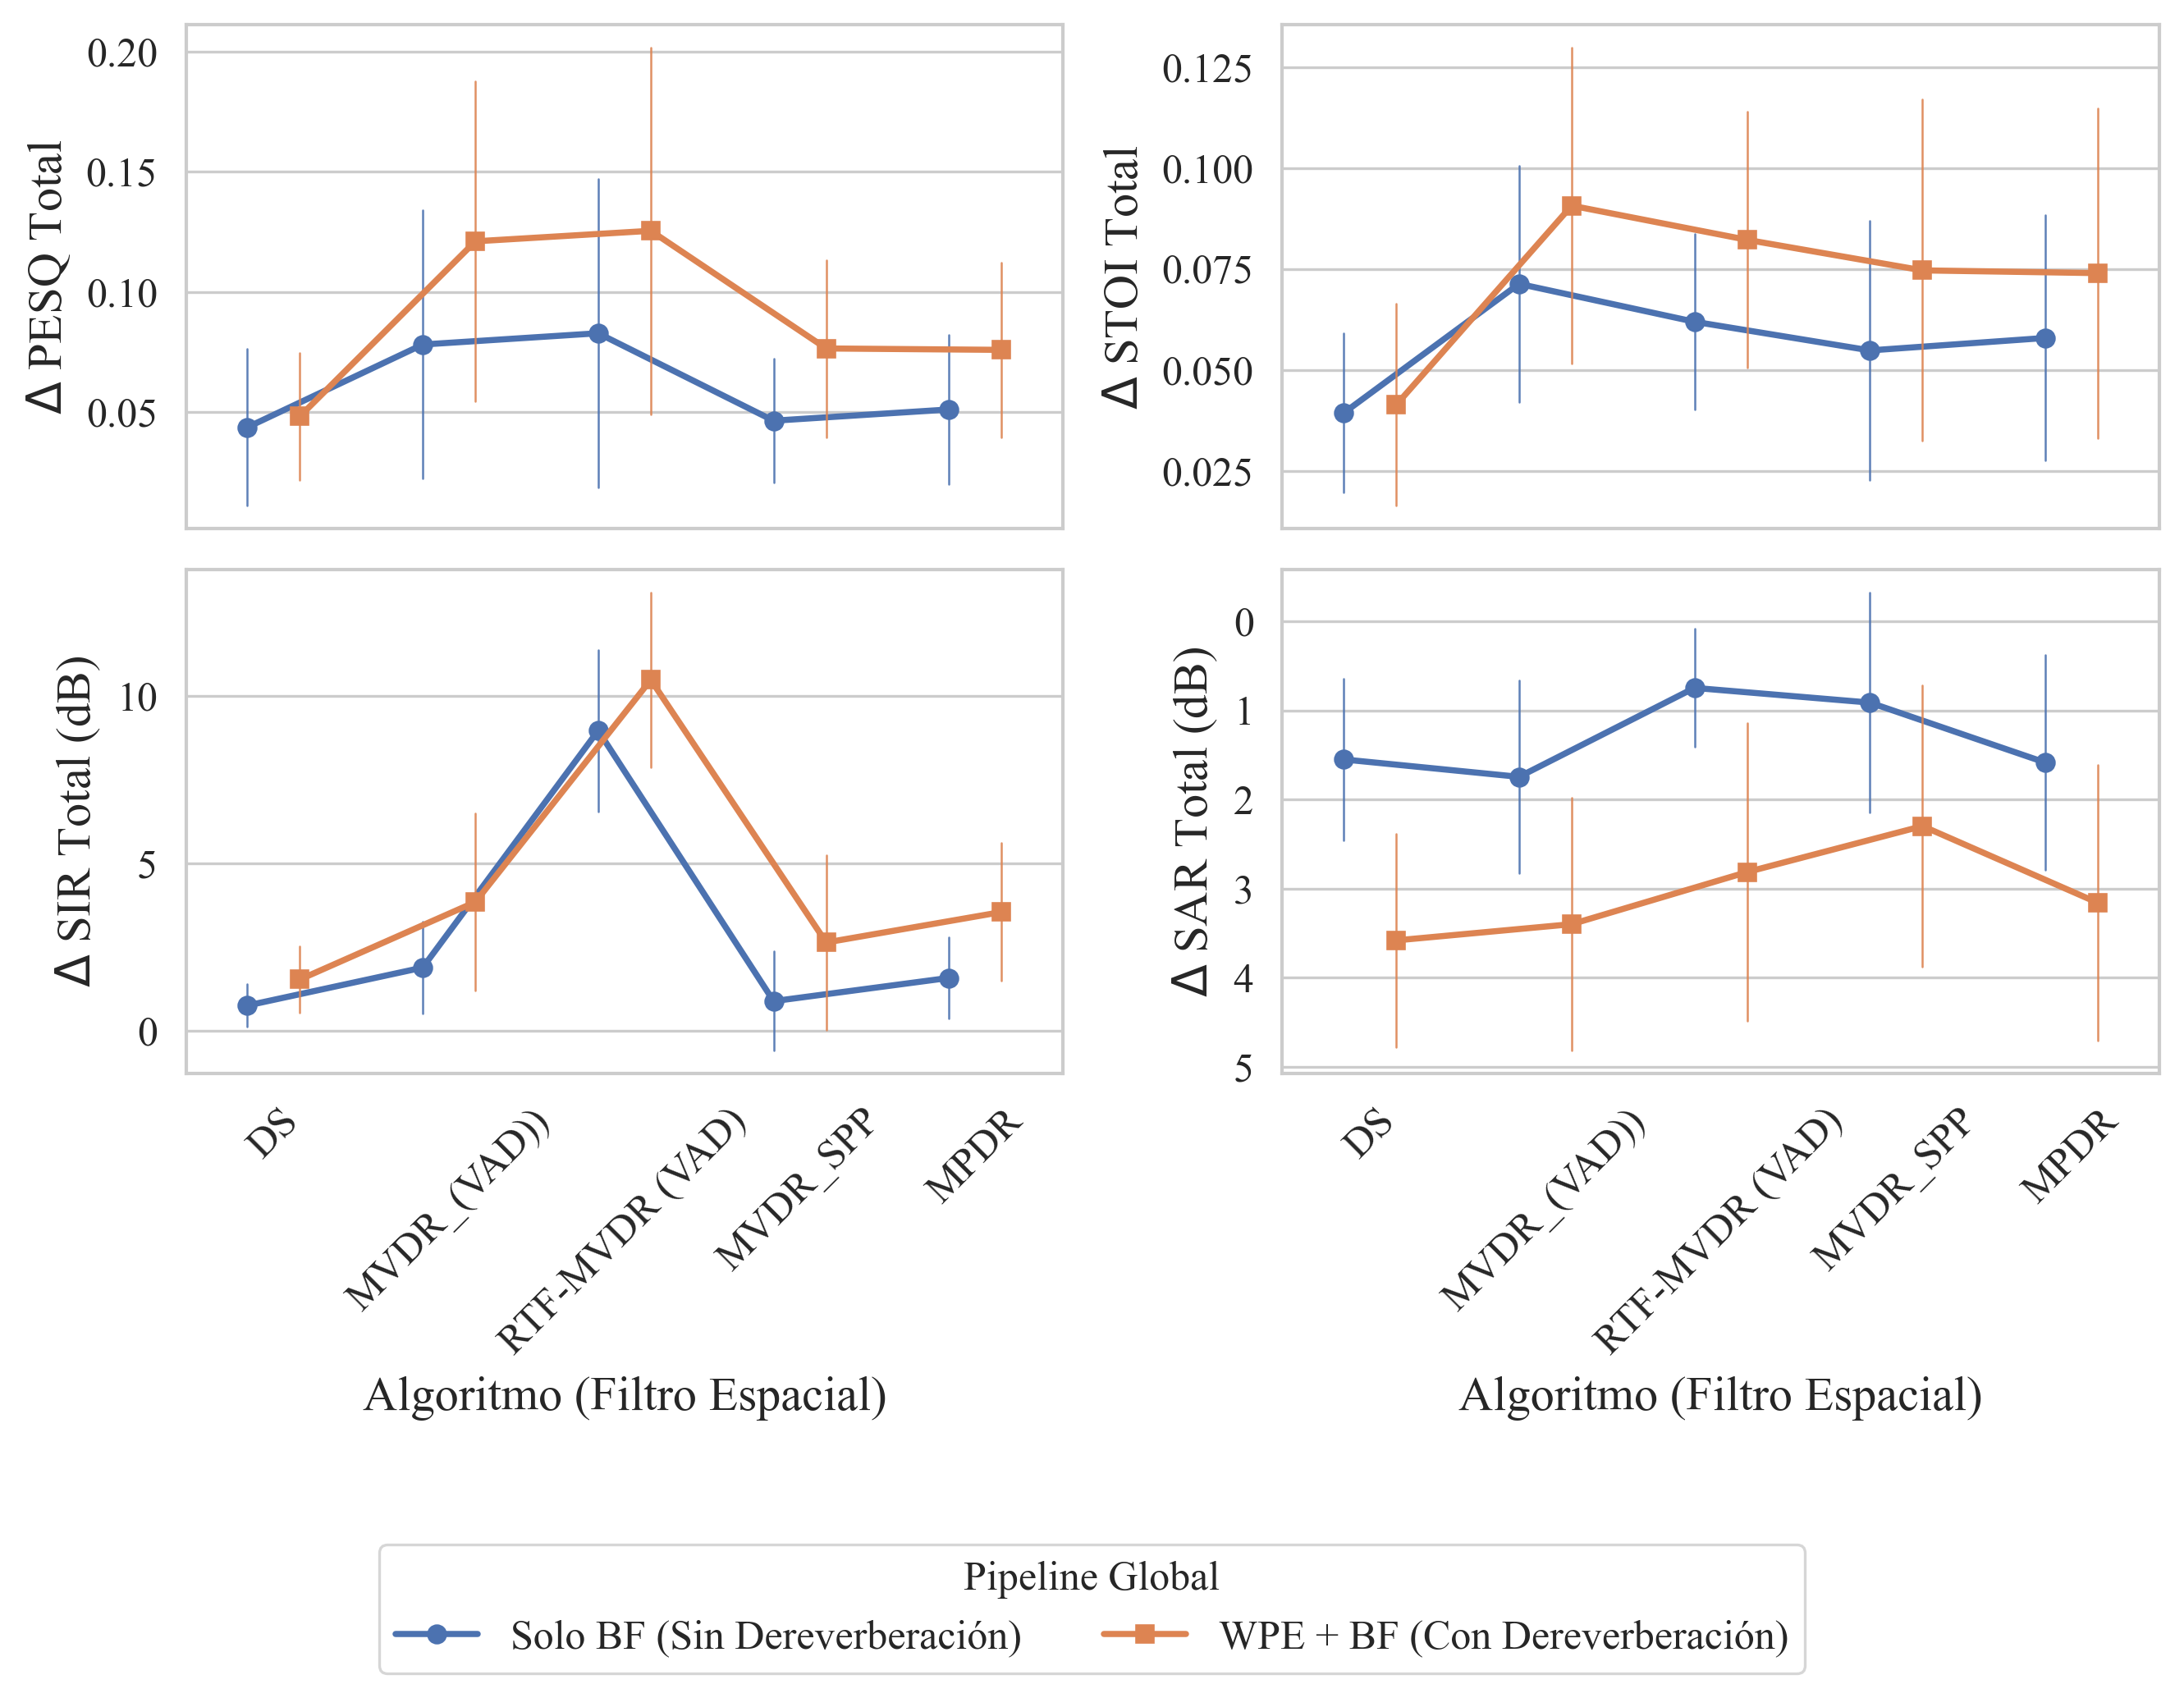

In [34]:
# ==============================================================================
# BLOCK: GENERATE GLOBAL PERFORMANCE PLOT VS PROCESSORS (WITH AND WITHOUT WPE)
# ==============================================================================

def plot_global_wpe_vs_no_wpe_compact(df):
    """
    Generates a 2x2 grid plotting the global performance delta (PESQ, STOI, SIR, SAR) 
    comparing the pipeline with and without WPE (dereverberation) across all algorithms.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates total performance across different spatial filters.
    """
    # Create a copy and map the WPE condition for the legend
    df_plot = df.copy()
    df_plot['Condición WPE'] = df_plot['use_wpe'].map({True: 'WPE + BF (Con Dereverberación)', False: 'Solo BF (Sin Dereverberación)'})
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_tot_PESQ': r'$\Delta$ PESQ Total',
        'Delta_tot_STOI': r'$\Delta$ STOI Total',
        'Delta_tot_SIR': r'$\Delta$ SIR Total (dB)',
        'Delta_tot_SAR': r'$\Delta$ SAR Total (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
    axes = axes.flatten()
    
    # Get unique conditions to assign markers properly
    conditions = df_plot['Condición WPE'].unique()
    markers = ['o', 's']
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='processor', 
            y=metric_col, 
            hue='Condición WPE', 
            dodge=0.3, 
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0, 
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Algoritmo (Filtro Espacial)') 
        ax.set_ylabel(y_label)
        
        # Rotate X-axis labels to prevent overlapping of long algorithm names
        ax.tick_params(axis='x', rotation=45) 
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        # Invert Y-axis specifically for SAR
        if 'SAR' in metric_col:
            ax.invert_yaxis() 
            
    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Pipeline Global',
        loc='center', 
        bbox_to_anchor=(0.5, -0.1), # Positioned below the subplots
        ncol=2, 
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "deltas_totales_wpe_vs_bf.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_global_wpe_vs_no_wpe_compact(df_metrics)

Presentation plot optimized and saved at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\global_wpe_comparison_sdr_barplot_presentation.pdf


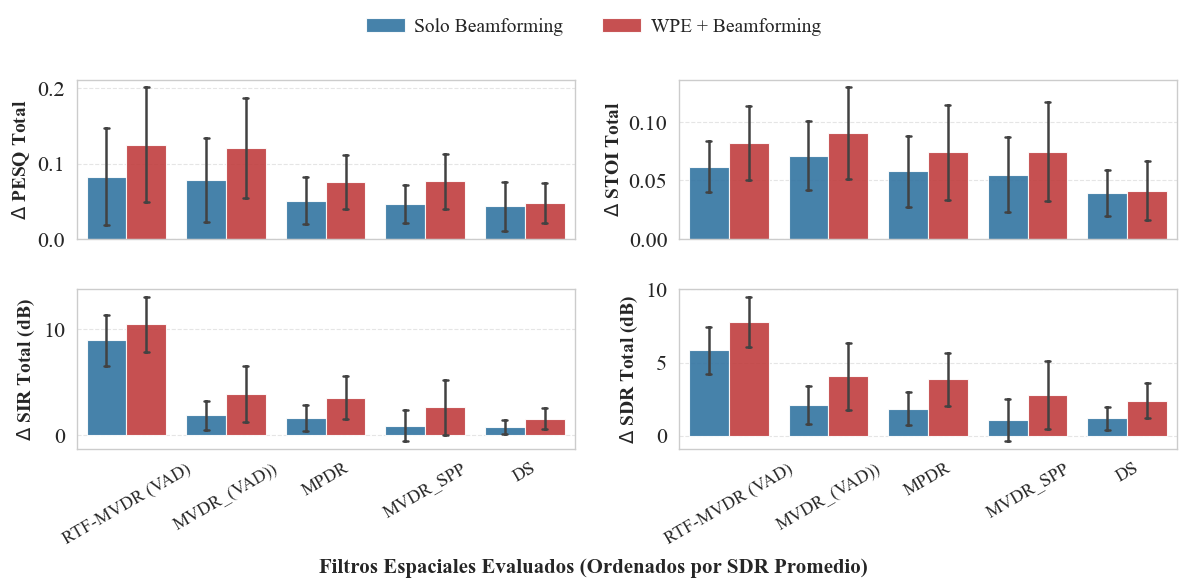

In [48]:
# ==============================================================================
# BLOCK: GLOBAL PERFORMANCE (WPE VS NO-WPE) - PRESENTATION OPTIMIZED
# ==============================================================================

def plot_global_wpe_vs_no_wpe_barplot_optimized(df):
    """
    Generates a 2x2 grid using bar plots heavily optimized for presentations.
    Increases font sizes, optimizes layout space, and places the legend 
    horizontally at the top to maximize the plotting area.
    Orders the processors on the X-axis from best to worst based on average Delta_tot_SDR.
    """
    # Create a copy and map the WPE condition for the legend
    df_plot = df.copy()
    df_plot['Condición WPE'] = df_plot['use_wpe'].map({
        True: 'WPE + Beamforming', 
        False: 'Solo Beamforming'
    })
    
    # Determine the order of processors from best to worst based on average SDR
    processor_order = df_plot.groupby('processor')['Delta_tot_SDR'].mean().sort_values(ascending=False).index.tolist()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_tot_PESQ': r'$\Delta$ PESQ Total',
        'Delta_tot_STOI': r'$\Delta$ STOI Total',
        'Delta_tot_SIR': r'$\Delta$ SIR Total (dB)',
        'Delta_tot_SDR': r'$\Delta$ SDR Total (dB)'
    }
    
    # Create a 2x2 subplot grid with dimensions suited for a 16:9 presentation slide
    fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)
    axes = axes.flatten()
    
    # Define a high-contrast color palette for projection
    palette = {"WPE + Beamforming": "#d62728", "Solo Beamforming": "#1f77b4"}
    
    # Generate each subplot using a bar plot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Barplot generation applying the calculated order
        sns.barplot(
            data=df_plot, 
            x='processor', 
            y=metric_col, 
            hue='Condición WPE', 
            palette=palette,
            order=processor_order,       
            errorbar='sd',               
            capsize=0.1,                 
            err_kws={'linewidth': 1.8},  # Thicker error bars for distant viewing
            alpha=0.9,                   
            ax=ax
        )
        
        # Increase font sizes for the Y-axis labels
        ax.set_ylabel(y_label, fontweight='bold', fontsize=14)
        ax.set_xlabel('') # Clear individual X-labels to avoid clutter
        
        # Increase font sizes for the tick marks
        ax.tick_params(axis='y', labelsize=16)
        
        # Add X-axis elements only to the bottom subplots
        if idx >= 2:
            ax.tick_params(axis='x', rotation=30, labelsize=13)
            
        # Remove redundant individual legends inside the subplots
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
        # Add a subtle horizontal grid to make comparing bar heights easier
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Add a global title for the X-axis placed appropriately at the bottom
    fig.text(0.5, -0.02, 'Filtros Espaciales Evaluados (Ordenados por SDR Promedio)', ha='center', fontsize=15, fontweight='bold')

    # Adjust the layout spacing to maximize subplot area and avoid overlaps
    plt.tight_layout(h_pad=2.0, w_pad=2.0)
    
    # Extract unique handles and labels from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Place a horizontal legend at the top center of the entire figure
    fig.legend(
        handles, labels, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.02),  # Positioned safely above the subplots
        ncol=2,                      # Horizontal alignment
        fontsize=14,                 # Larger legend font
        frameon=False,               # Remove the box for a cleaner aesthetic
        handletextpad=0.5,
        columnspacing=2.0
    )
    
    # Save high-quality version compatible with LaTeX/PDF presentations
    output_path = os.path.join(FIGURES_DIR, "global_wpe_comparison_sdr_barplot_presentation.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Presentation plot optimized and saved at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_global_wpe_vs_no_wpe_barplot_optimized(df_metrics)